In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('sci.mplstyle')

In [2]:
t, x, temp = np.loadtxt("truyen_nhiet.dat", comments='#', usecols=(2,3,4), unpack=True)

nt = len(np.unique(t))
nx = len(np.unique(x))

t = t.reshape((nt, nx))
x = x.reshape((nt, nx))
temp = temp.reshape((nt, nx))

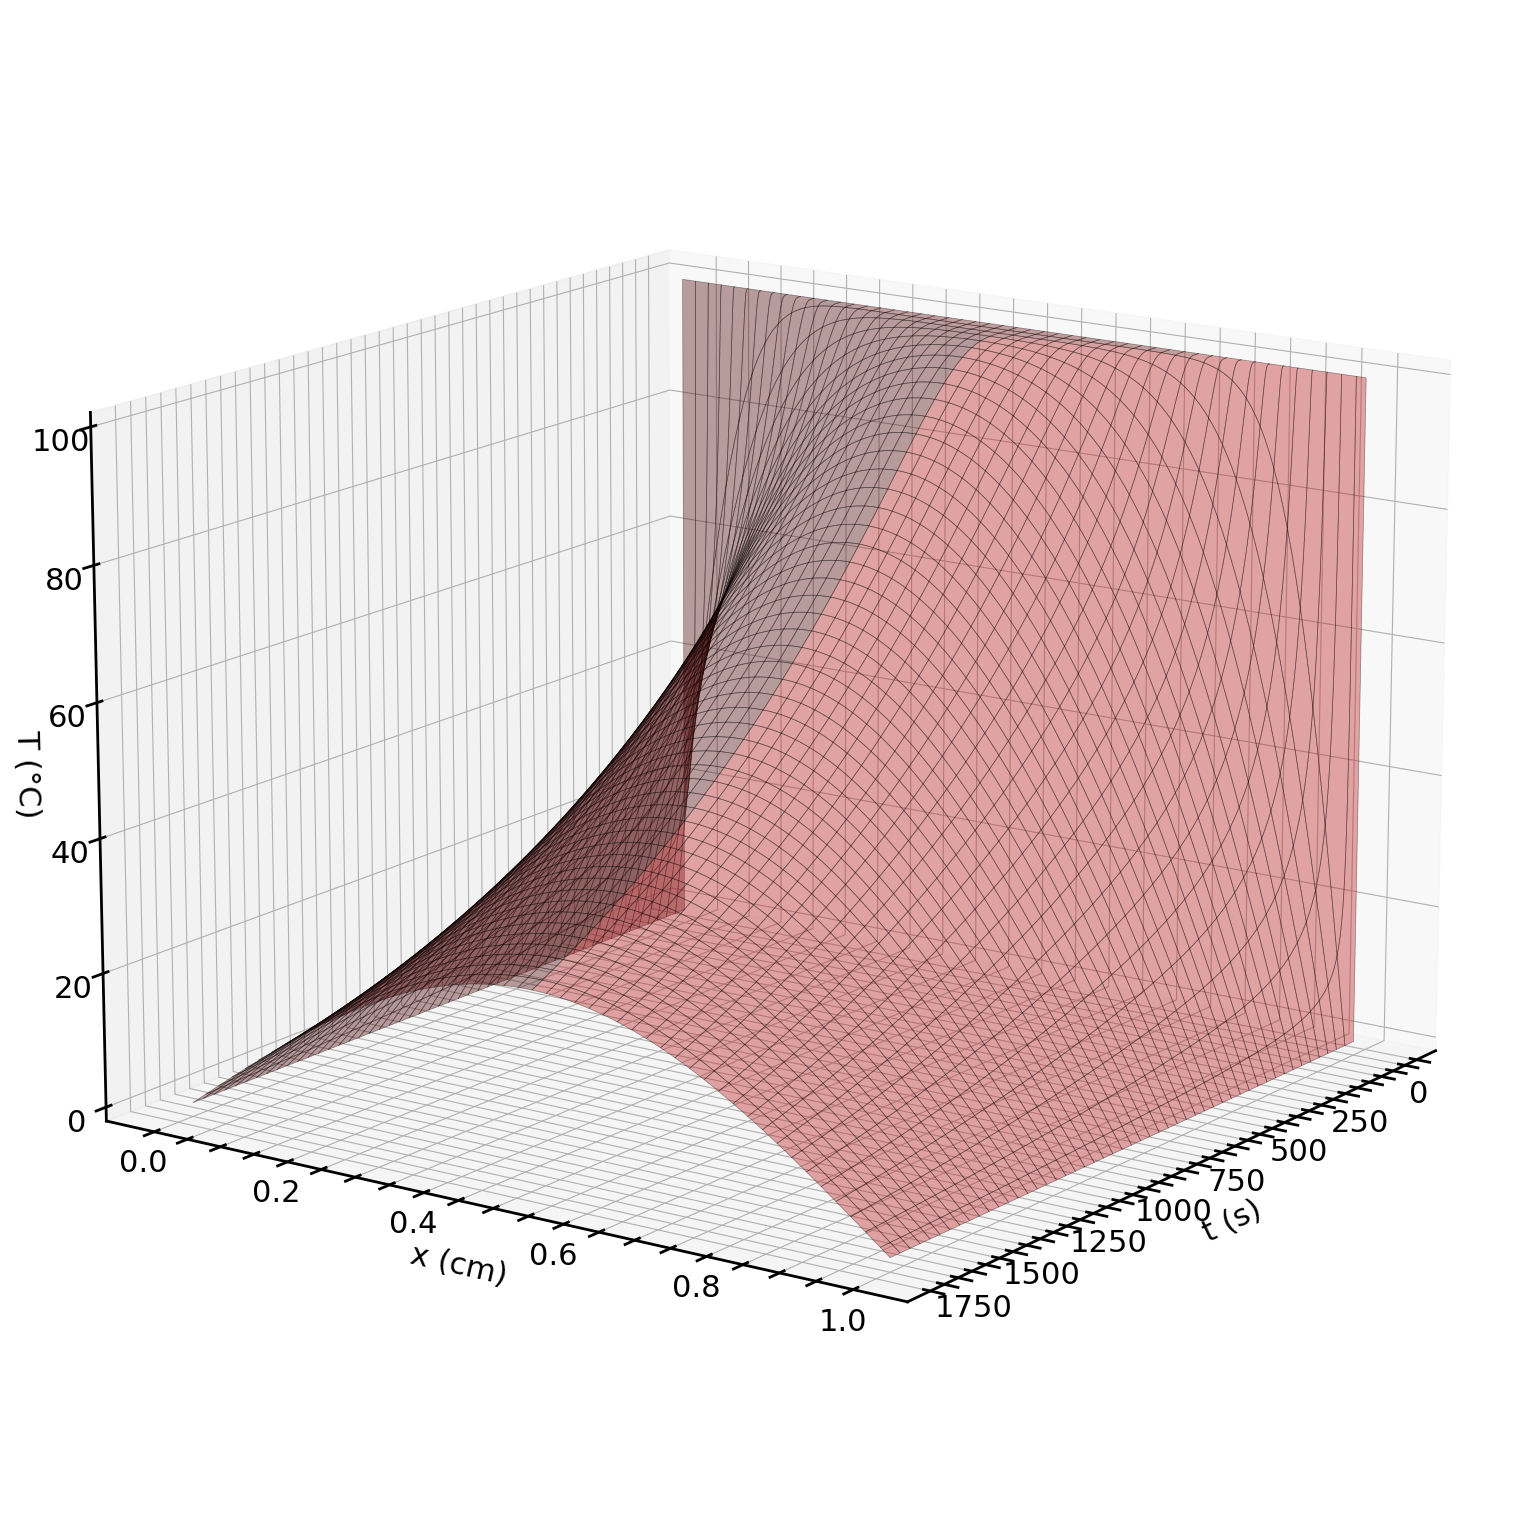

In [3]:
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_position([0.10, 0.05, 0.75, 0.90])  # width 0.75 thay vì 0.80


ax.plot_surface(t, x, temp, color='C1', alpha=0.4, edgecolor='black', linewidth=0.5)

ax.set_xlabel('t (s)', labelpad=12)
ax.set_ylabel('x (cm)', labelpad=12)
ax.set_zlabel('T (°C)', labelpad=8)

ax.tick_params(axis='x', pad=2)
ax.tick_params(axis='y', pad=2)
ax.tick_params(axis='z', pad=4)

ax.view_init(elev=15, azim=35)

plt.savefig("BTVN7-backward-nhietdo-3D.png", dpi=300)
plt.show()

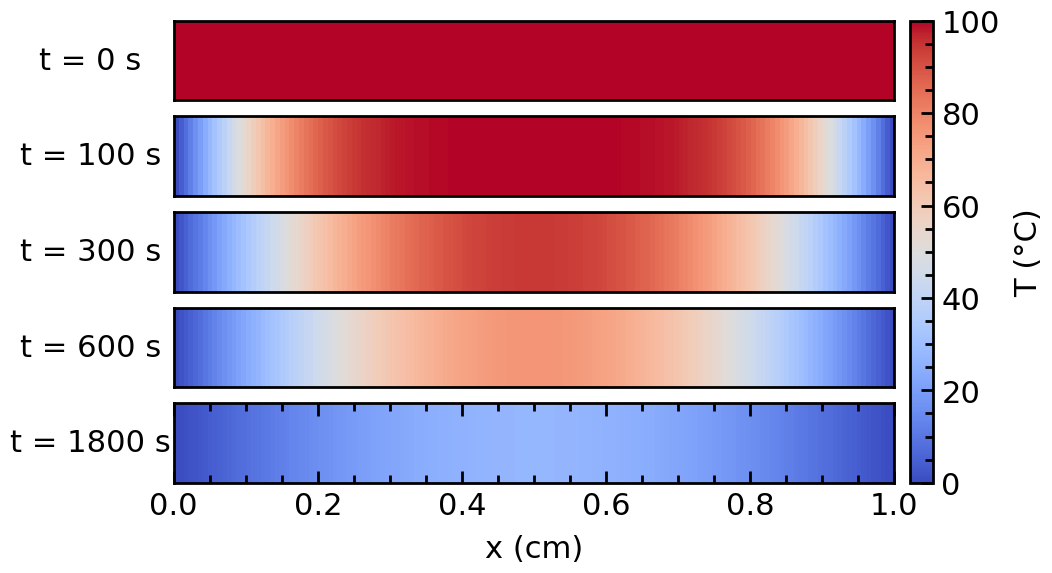

In [4]:
t_targets = [0, 100, 300, 600, t.max()]
t_unique = np.unique(t)

fig, axes = plt.subplots(5, 1, figsize=(10, 6))  # 5 subplots

vmin = temp.min()
vmax = temp.max()

labels = ['t = 0 s', 't = 100 s', 't = 300 s', 't = 600 s', f't = {t.max():.0f} s']  # 5 labels

for i, (ax, t_target, label) in enumerate(zip(axes, t_targets, labels)):
    idx = np.argmin(np.abs(t_unique - t_target))
    
    temp_row = temp[idx, :]
    x_row    = x[idx, :]
    
    im = ax.imshow(
        temp_row.reshape(1, -1),
        aspect='auto',
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        extent=[x_row.min(), x_row.max(), 0, 1]
    )
    
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, labelpad=60, va='center')
    
    if i < 4:
        ax.set_xticks([])
    else:
        ax.set_xlabel('x (cm)')

cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('T (°C)')

plt.savefig("BTVN7-nhietdo-thanh.png", dpi=300, bbox_inches='tight')
plt.show()